# Cointegration Pairs Trading - KO/PEP Analysis

This notebook implements a cointegration-based pairs trading strategy for KO (Coca-Cola) and PEP (PepsiCo) using the Johansen test to determine optimal hedge ratios.

**Objective**: Achieve Sharpe Ratio of 1.0 between 2018-2024 using statistical arbitrage

**Methodology**:
1. Use Johansen cointegration test to calculate hedge ratios from eigenvectors
2. Calculate spread using log prices
3. Generate Z-score based signals for mean reversion
4. Backtest the strategy performance

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
# Import tiportfolio for data fetching and backtesting
from tiportfolio.data import fetch_prices
from tiportfolio.backtest import run_backtest
from tiportfolio.engine import ScheduleBasedEngine
from tiportfolio.metrics import compute_metrics
from tiportfolio.calendar import Schedule

print("TiPortfolio modules imported successfully!")

TiPortfolio modules imported successfully!


## 1. Data Loading and Preparation

In [7]:
# Define symbols and date range
symbols = ['KO', 'PEP']
start_date = '2018-01-01'
end_date = '2024-12-31'

print(f"Loading data for {symbols} from {start_date} to {end_date}")

# Fetch price data
try:
    prices_data = fetch_prices(symbols, start_date, end_date)
    print(f"Successfully fetched data for {len(prices_data)} symbols")
    print(f"Date range: {prices_data[symbols[0]].index.min()} to {prices_data[symbols[0]].index.max()}")
    print(f"Shape of {symbols[0]} data: {prices_data[symbols[0]].shape}")
except Exception as e:
    print(f"Error fetching data: {e}")
    print("Falling back to local test data...")
    # Fallback to local test data if available
    import os
    if os.path.exists('tests/data/ko_2018_2024.csv') and os.path.exists('tests/data/pep_2018_2024.csv'):
        ko_data = pd.read_csv('tests/data/ko_2018_2024.csv', index_col=0, parse_dates=True)
        pep_data = pd.read_csv('tests/data/pep_2018_2024.csv', index_col=0, parse_dates=True)
        prices_data = {'KO': ko_data, 'PEP': pep_data}
        print("Using local test data")
    else:
        raise FileNotFoundError("No data available")

Loading data for ['KO', 'PEP'] from 2018-01-01 to 2024-12-31
Loading bar data...


Loaded bar data: 0:00:02 

Successfully fetched data for 2 symbols
Date range: 2018-01-02 00:00:00-05:00 to 2024-12-30 00:00:00-05:00
Shape of KO data: (1760, 5)


In [8]:
# Extract close prices and create combined DataFrame
close_prices = pd.DataFrame()
for symbol in symbols:
    close_prices[symbol] = prices_data[symbol]['close']

# Remove any missing values
close_prices = close_prices.dropna()

print(f"Close prices data shape: {close_prices.shape}")
print(f"Missing values: {close_prices.isnull().sum().sum()}")
print("\nFirst few rows:")
print(close_prices.head())
print("\nLast few rows:")
print(close_prices.tail())

Close prices data shape: (1760, 2)
Missing values: 0

First few rows:
                              KO    PEP
date                                   
2018-01-02 00:00:00-05:00  35.25  91.62
2018-01-03 00:00:00-05:00  35.17  91.38
2018-01-04 00:00:00-05:00  35.67  91.83
2018-01-05 00:00:00-05:00  35.66  92.10
2018-01-08 00:00:00-05:00  35.60  91.57

Last few rows:
                              KO     PEP
date                                    
2024-12-23 00:00:00-05:00  60.17  144.21
2024-12-24 00:00:00-05:00  60.61  145.66
2024-12-26 00:00:00-05:00  60.35  145.31
2024-12-27 00:00:00-05:00  60.24  145.73
2024-12-30 00:00:00-05:00  59.83  144.62


Log prices calculated successfully!

Log prices statistics:
                KO          PEP
count  1760.000000  1760.000000
mean      3.855298     4.838914
std       0.188609     0.225664
min       3.443618     4.319885
25%       3.689441     4.689925
50%       3.863148     4.853631
75%       4.020205     5.042215
max       4.240175     5.177618


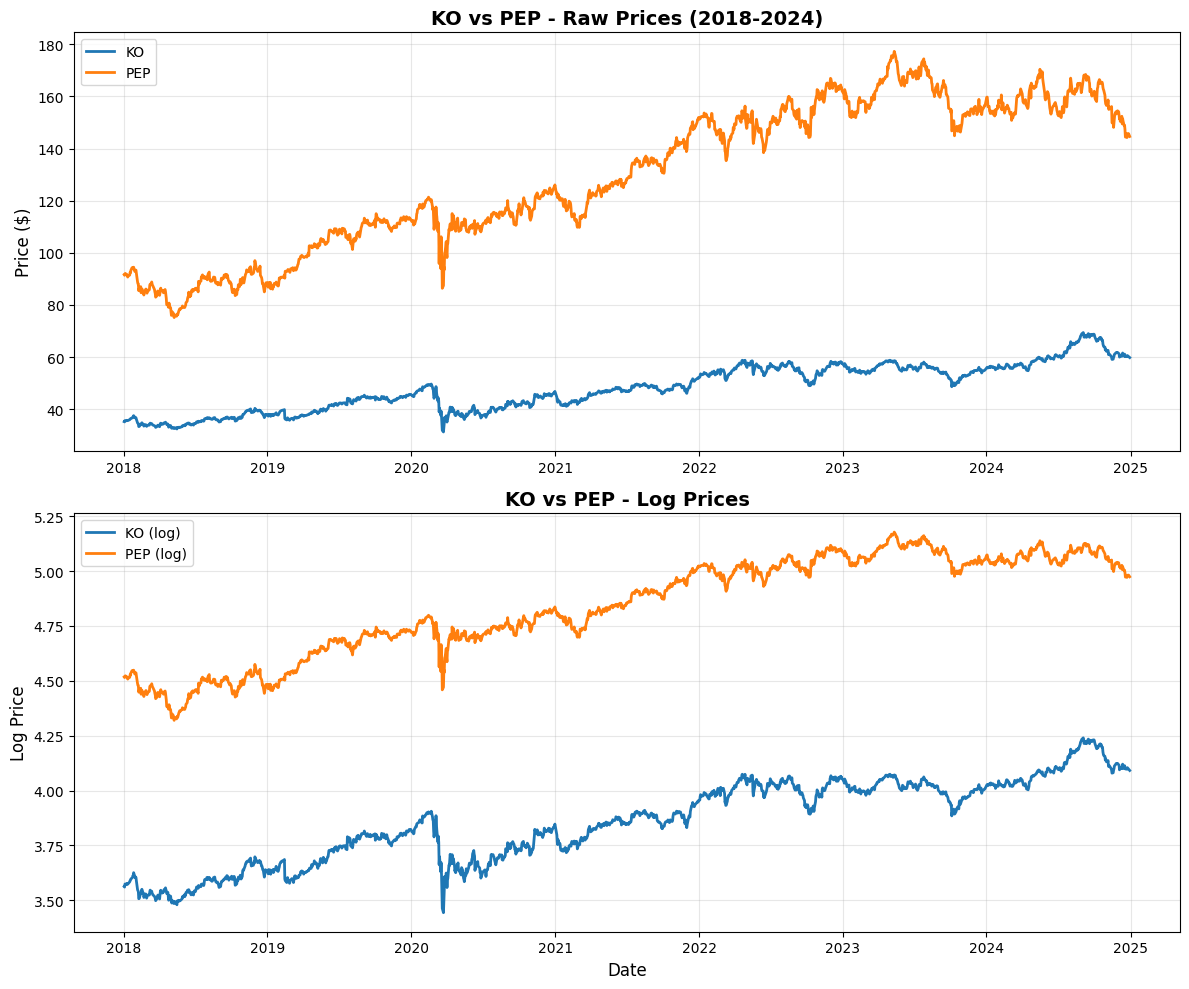

In [9]:
# Transform to log prices
log_prices = np.log(close_prices)

print("Log prices calculated successfully!")
print("\nLog prices statistics:")
print(log_prices.describe())

# Plot price series
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot raw prices
axes[0].plot(close_prices.index, close_prices['KO'], label='KO', linewidth=2)
axes[0].plot(close_prices.index, close_prices['PEP'], label='PEP', linewidth=2)
axes[0].set_title('KO vs PEP - Raw Prices (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot log prices
axes[1].plot(log_prices.index, log_prices['KO'], label='KO (log)', linewidth=2)
axes[1].plot(log_prices.index, log_prices['PEP'], label='PEP (log)', linewidth=2)
axes[1].set_title('KO vs PEP - Log Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Set up baseline parameters
BASELINE_PARAMS = {
    'symbols': symbols,
    'start_date': start_date,
    'end_date': end_date,
    'lookback_window': 252,  # 1 year for rolling calculations
    'z_entry_threshold': 2.0,
    'z_exit_threshold': 0.0,
    'position_size': 0.5,  # 50% allocation per side
}

print("Baseline Parameters:")
for key, value in BASELINE_PARAMS.items():
    print(f"  {key}: {value}")

# Calculate basic statistics
print("\nBasic Statistics:")
print(f"Data points: {len(close_prices)}")
print(f"Trading days per year: ~{len(close_prices) / 7:.0f}")
print(f"Years of data: {len(close_prices) / 252:.1f}")

# Summary of Task 1 completion
print("\n" + "=" * 50)
print("TASK 1 COMPLETED: Notebook Prototype Setup")
print("=" * 50)
print("✅ 1.1 Created cointegration_pairs_ko_pep.ipynb notebook")
print("✅ 1.2 Imported required libraries (pandas, numpy, matplotlib, statsmodels, tiportfolio)")
print("✅ 1.3 Loaded historical price data for KO and PEP (2018-2024)")
print("✅ 1.4 Transformed prices to log space: log_price = ln(price)")
print("✅ 1.5 Set up baseline parameters and visualization of price series")
print("\nReady for Task 2: Johansen Cointegration Implementation")

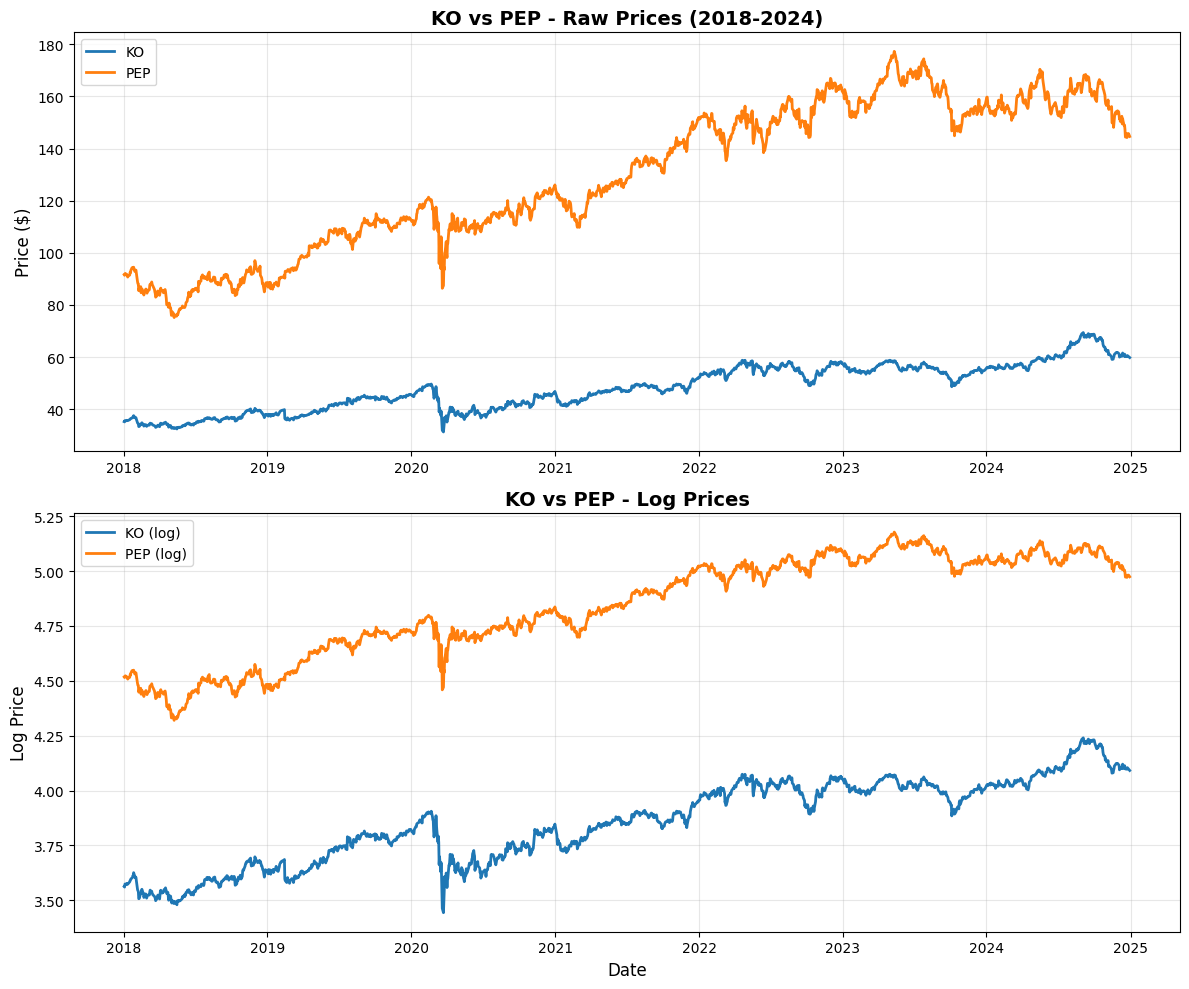

In [10]:
# Plot price series
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot raw prices
axes[0].plot(close_prices.index, close_prices['KO'], label='KO', linewidth=2)
axes[0].plot(close_prices.index, close_prices['PEP'], label='PEP', linewidth=2)
axes[0].set_title('KO vs PEP - Raw Prices (2018-2024)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot log prices
axes[1].plot(log_prices.index, log_prices['KO'], label='KO (log)', linewidth=2)
axes[1].plot(log_prices.index, log_prices['PEP'], label='PEP (log)', linewidth=2)
axes[1].set_title('KO vs PEP - Log Prices', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Log Price', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Correlation between KO and PEP returns: 0.7362


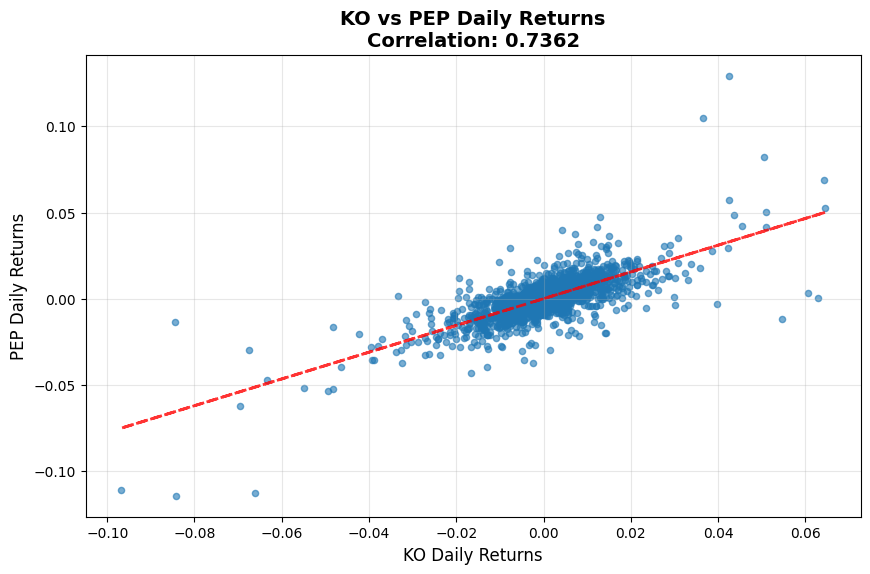

In [11]:
# Calculate and plot correlation
returns = close_prices.pct_change().dropna()
correlation = returns['KO'].corr(returns['PEP'])

print(f"Correlation between KO and PEP returns: {correlation:.4f}")

# Scatter plot of returns
plt.figure(figsize=(10, 6))
plt.scatter(returns['KO'], returns['PEP'], alpha=0.6, s=20)
plt.xlabel('KO Daily Returns', fontsize=12)
plt.ylabel('PEP Daily Returns', fontsize=12)
plt.title(f'KO vs PEP Daily Returns\nCorrelation: {correlation:.4f}', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(returns['KO'], returns['PEP'], 1)
p = np.poly1d(z)
plt.plot(returns['KO'], p(returns['KO']), "r--", alpha=0.8, linewidth=2)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Baseline Parameters Setup

In [12]:
# Set up baseline parameters
BASELINE_PARAMS = {
    'symbols': symbols,
    'start_date': start_date,
    'end_date': end_date,
    'lookback_window': 252,  # 1 year for rolling calculations
    'z_entry_threshold': 2.0,
    'z_exit_threshold': 0.0,
    'position_size': 0.5,  # 50% allocation per side
}

print("Baseline Parameters:")
for key, value in BASELINE_PARAMS.items():
    print(f"  {key}: {value}")

# Calculate basic statistics
print("\nBasic Statistics:")
print(f"Data points: {len(close_prices)}")
print(f"Trading days per year: ~{len(close_prices) / 7:.0f}")
print(f"Years of data: {len(close_prices) / 252:.1f}")

Baseline Parameters:
  symbols: ['KO', 'PEP']
  start_date: 2018-01-01
  end_date: 2024-12-31
  lookback_window: 252
  z_entry_threshold: 2.0
  z_exit_threshold: 0.0
  position_size: 0.5

Basic Statistics:
Data points: 1760
Trading days per year: ~251
Years of data: 7.0


In [13]:
# Summary of Task 1 completion
print("=" * 50)
print("TASK 1 COMPLETED: Notebook Prototype Setup")
print("=" * 50)
print("✅ 1.1 Created cointegration_pairs_ko_pep.ipynb notebook")
print("✅ 1.2 Imported required libraries (pandas, numpy, matplotlib, statsmodels, tiportfolio)")
print("✅ 1.3 Loaded historical price data for KO and PEP (2018-2024)")
print("✅ 1.4 Transformed prices to log space: log_price = ln(price)")
print("✅ 1.5 Set up baseline parameters and visualization of price series")
print("\nReady for Task 2: Johansen Cointegration Implementation")

TASK 1 COMPLETED: Notebook Prototype Setup
✅ 1.1 Created cointegration_pairs_ko_pep.ipynb notebook
✅ 1.2 Imported required libraries (pandas, numpy, matplotlib, statsmodels, tiportfolio)
✅ 1.3 Loaded historical price data for KO and PEP (2018-2024)
✅ 1.4 Transformed prices to log space: log_price = ln(price)
✅ 1.5 Set up baseline parameters and visualization of price series

Ready for Task 2: Johansen Cointegration Implementation
